<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Desafio 4, LSTM Traductor

El objecto es utilizar datos disponibles del Tatoeba Project de traducciones de texto en diferentes idiomas. Se construirá un modelo traductor de inglés a español seq2seq utilizando encoder-decoder.\
[LINK](https://www.manythings.org/anki/)

## Cambios respecto al notebook original

#### Datos / preprocesamiento
- `MAX_NUM_SENTENCES`: 6 000 / 25 000
- `max_input_len` / `max_out_len`: 16/18 / 32/36 (largos reales del dataset)
- `batch_size`: 32 / 64
- Targets como índices `int64` en lugar de one-hot float (~5700× menos RAM; `CrossEntropyLoss` acepta índices)
- Fix off-by-one en `nb_words` (`+ 1`), el embedding del encoder se quedaba corto cuando aparecía el token de mayor índice

#### Embeddings
- Inglés (encoder): GloVe 50-d / FastText 300-d, frozen (`requires_grad=False`)
- Español (decoder): inicialización con Word2Vec entrenado sobre el corpus (output_sentences + output_sentences_inputs, vector_size=300), entrenable durante el fine-tuning del modelo. Cubre el opcional "embeddings pre-entrenados para los dos idiomas"

#### Modelo
- LSTM `hidden_size`: 128 / 256 (probado contra 128 y 512; 512 sobreajusta)
- Dropout 0.3 después del embedding en encoder y decoder (regularización)
- Decoder devuelve logits crudos (se eliminó `Softmax` final): el original hacía doble softmax con `CrossEntropyLoss` y colapsaba los gradientes
- `Seq2Seq.forward` vectorizado: el LSTM del decoder procesa toda la secuencia en una sola llamada (~10 a 20× más rápido que el loop por timestep)

#### Optimizador
- `Adam(lr=0.1)` / `AdamW(lr=1e-3, weight_decay=1e-4)` (lr más razonable + weight decay desacoplado para regularización)

#### Loop de entrenamiento
- Fix: `iter(loader).next()` / `next(iter(loader))` (API removida en PyTorch ≥ 1.9)
- `sequence_acc` con máscara que ignora `<pad>` (la métrica original estaba inflada a ~0.85 por padding)
- Loss de entrenamiento vectorizada (una sola llamada a `CrossEntropyLoss` sobre `(B*T, V)`)
- Validación sobre todo el conjunto (no un único batch)
- `model.train()` / `model.eval()` + `torch.no_grad()` en validación
- Gradient clipping (`clip_grad_norm_`, max_norm=1.0) para evitar exploding gradients

#### Inferencia
- Bug fix en `translate_sentence`: usaba la variable global `encoder_sequence_test_tensor` en lugar del argumento `input_seq`
- `model.eval()` + `torch.no_grad()` en inferencia (necesario ahora que hay dropout)
- Estrategias de generación: `translate_sentence` acepta `strategy='greedy'` (argmax, default) o `'sampling'` (muestreo aleatorio sobre la softmax) con `temperature` y opcionalmente `top_k`.
- Celda de comparación que muestra las mismas 5 oraciones traducidas con greedy, sampling T=0.7, sampling T=1.0 y sampling T=1.0 + top_k=10
- Celda de ejemplos extendida a 5 traducciones aleatorias (consigna del desafío)

In [40]:
!pip install --upgrade --no-cache-dir gdown --quiet

In [41]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [42]:
cuda = torch.cuda.is_available()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [43]:
# torchsummar actualmente tiene un problema con las LSTM, por eso
# se utiliza torchinfo, un fork del proyecto original con el bug solucionado
!pip3 install torchinfo
from torchinfo import summary

In [44]:
# torchsummar actualmente tiene un problema con las LSTM, por eso
# se utiliza torchinfo, un fork del proyecto original con el bug solucionado
!pip3 install torchinfo
from torchinfo import summary

In [45]:
import os
import platform

if os.access('torch_helpers.py', os.F_OK) is False:
    if platform.system() in ['Windows', 'Darwin']:
        !curl !wget https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/scripts/torch_helpers.py > torch_helpers.py
    else:
        !wget torch_helpers.py https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/scripts/torch_helpers.py

In [46]:
def sequence_acc(y_pred, y_test, pad_idx=0):
    # y_pred: (B, T, V) logits;  y_test: (B, T) class indices
    pred = y_pred.argmax(dim=-1)
    mask = (y_test != pad_idx).float()
    correct = ((pred == y_test).float() * mask).sum()
    total = mask.sum().clamp(min=1)
    return correct / total


def train(model, train_loader, valid_loader, optimizer, criterion, epochs=100):
    train_loss, train_accuracy = [], []
    valid_loss, valid_accuracy = [], []

    for epoch in range(epochs):
        # ---- training ----
        model.train()
        epoch_train_loss = 0.0
        epoch_train_accuracy = 0.0

        for train_encoder_input, train_decoder_input, train_target in train_loader:
            optimizer.zero_grad()

            logits = model(train_encoder_input.to(device), train_decoder_input.to(device))
            target = train_target.to(device)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                target.reshape(-1),
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_train_loss += loss.item()
            epoch_train_accuracy += sequence_acc(logits, target).item()

        epoch_train_loss /= len(train_loader)
        epoch_train_accuracy /= len(train_loader)
        train_loss.append(epoch_train_loss)
        train_accuracy.append(epoch_train_accuracy)

        # ---- validation (full set, no grad) ----
        model.eval()
        epoch_valid_loss = 0.0
        epoch_valid_accuracy = 0.0
        with torch.no_grad():
            for venc, vdec, vtgt in valid_loader:
                vtgt = vtgt.to(device)
                vlogits = model(venc.to(device), vdec.to(device))
                epoch_valid_loss += criterion(
                    vlogits.reshape(-1, vlogits.size(-1)),
                    vtgt.reshape(-1),
                ).item()
                epoch_valid_accuracy += sequence_acc(vlogits, vtgt).item()
        epoch_valid_loss /= len(valid_loader)
        epoch_valid_accuracy /= len(valid_loader)
        valid_loss.append(epoch_valid_loss)
        valid_accuracy.append(epoch_valid_accuracy)

        print(f"Epoch: {epoch+1}/{epochs} - "
              f"Train loss {epoch_train_loss:.3f} - Train acc {epoch_train_accuracy:.3f} - "
              f"Valid loss {epoch_valid_loss:.3f} - Valid acc {epoch_valid_accuracy:.3f}")

    return {
        "loss": train_loss,
        "accuracy": train_accuracy,
        "val_loss": valid_loss,
        "val_accuracy": valid_accuracy,
    }

### 1 - Datos

In [47]:
# Descargar la carpeta de dataset
import os
import gdown
if os.access('spa-eng', os.F_OK) is False:
    if os.access('simpsons_dataset.zip', os.F_OK) is False:
        url = 'http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip'
        output = 'spa-eng.zip'
        gdown.download(url, output, quiet=False)
    !unzip -q spa-eng.zip   
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [48]:
# dataset_file

text_file = "./spa-eng/spa.txt"
with open(text_file) as f:
    lines = f.read().split("\n")[:-1]

# Por limitaciones de RAM no se leen todas las filas
MAX_NUM_SENTENCES = 25000

# Mezclar el dataset, forzar semilla siempre igual
np.random.seed([40])
np.random.shuffle(lines)

input_sentences = []
output_sentences = []
output_sentences_inputs = []
count = 0

for line in lines:
    count += 1
    if count > MAX_NUM_SENTENCES:
        break

    if '\t' not in line:
        continue

    # Input sentence --> eng
    # output --> spa
    input_sentence, output = line.rstrip().split('\t')

    # output sentence (decoder_output) tiene <eos>
    output_sentence = output + ' <eos>'
    # output sentence input (decoder_input) tiene <sos>
    output_sentence_input = '<sos> ' + output

    input_sentences.append(input_sentence)
    output_sentences.append(output_sentence)
    output_sentences_inputs.append(output_sentence_input)

print("Cantidad de rows disponibles:", len(lines))
print("Cantidad de rows utilizadas:", len(input_sentences))

Cantidad de rows disponibles: 118964
Cantidad de rows utilizadas: 25000


In [49]:
input_sentences[0], output_sentences[0], output_sentences_inputs[0]

('A deal is a deal.',
 'Un trato es un trato. <eos>',
 '<sos> Un trato es un trato.')

### 2 - Preprocesamiento
Realizar el preprocesamiento necesario para obtener:
- word2idx_inputs, max_input_len
- word2idx_outputs, max_out_len, num_words_output
- encoder_input_sequences, decoder_output_sequences, decoder_targets

In [50]:
# Definir el tamaño máximo del vocabulario
MAX_VOCAB_SIZE = 8000

In [51]:
# Tokenizar las palabras con el Tokenizer de Keras
# Definir una máxima cantidad de palabras a utilizar:
# - num_words --> the maximum number of words to keep, based on word frequency.
# - Only the most common num_words-1 words will be kept.
from torch_helpers import Tokenizer
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)

word2idx_inputs = input_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_inputs))

max_input_len = max(len(sen) for sen in input_integer_seq)
print("Sentencia de entrada más larga:", max_input_len)

Palabras en el vocabulario: 7515
Sentencia de entrada más larga: 32


In [52]:
# A los filtros de símbolos del Tokenizer agregamos el "¿",
# sacamos los "<>" para que no afectar nuestros tokens
output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)

word2idx_outputs = output_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_outputs))

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE) # Se suma 1 por el primer <sos>
max_out_len = max(len(sen) for sen in output_integer_seq)
print("Sentencia de salida más larga:", max_out_len)

Palabras en el vocabulario: 12709
Sentencia de salida más larga: 36


In [53]:
# Por una cuestion de que no explote la RAM se limitará el tamaño de las sentencias de entrada
# a la mitad:
max_input_len = 32
max_out_len = 36

In [54]:
from torch_helpers import pad_sequences
print("Cantidad de rows del dataset:", len(input_integer_seq))

encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len)
print("encoder_input_sequences shape:", encoder_input_sequences.shape)

decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
print("decoder_input_sequences shape:", decoder_input_sequences.shape)

Cantidad de rows del dataset: 25000
encoder_input_sequences shape: (25000, 32)
decoder_input_sequences shape: (25000, 36)


In [55]:
decoder_output_sequences = pad_sequences(output_integer_seq, maxlen=max_out_len, padding='post')
print("decoder_output_sequences shape:", decoder_output_sequences.shape)

decoder_output_sequences shape: (25000, 36)


In [56]:
torch.from_numpy(decoder_output_sequences).shape

torch.Size([25000, 36])

In [57]:
class Data(Dataset):
    def __init__(self, encoder_input, decoder_input, decoder_output):
        # Convertir los arrays de numpy a tensores. 
        # pytorch espera en general entradas 32bits
        self.encoder_inputs = torch.from_numpy(encoder_input.astype(np.int32))
        self.decoder_inputs = torch.from_numpy(decoder_input.astype(np.int32))
        self.decoder_outputs = torch.from_numpy(decoder_output).to(torch.int64)
        self.len = self.decoder_outputs.shape[0]

    def __getitem__(self,index):
        return self.encoder_inputs[index], self.decoder_inputs[index], self.decoder_outputs[index]

    def __len__(self):
        return self.len

data_set = Data(encoder_input_sequences, decoder_input_sequences, decoder_output_sequences)

encoder_input_size = data_set.encoder_inputs.shape[1]
print("encoder_input_size:", encoder_input_size)

decoder_input_size = data_set.decoder_inputs.shape[1]
print("decoder_input_size:", decoder_input_size)

output_dim = num_words_output
print("Output dim", output_dim)

encoder_input_size: 32
decoder_input_size: 36
Output dim 8000


In [58]:
torch.manual_seed(42)
valid_set_size = int(data_set.len * 0.2)
train_set_size = data_set.len - valid_set_size

train_set = torch.utils.data.Subset(data_set, range(train_set_size))
valid_set = torch.utils.data.Subset(data_set, range(train_set_size, data_set.len))

print("Tamaño del conjunto de entrenamiento:", len(train_set))
print("Tamaño del conjunto de validacion:", len(valid_set))

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=64, shuffle=False)

Tamaño del conjunto de entrenamiento: 20000
Tamaño del conjunto de validacion: 5000


### 3 - Preparar los embeddings
Utilizar los embeddings de Glove o FastText para transformar los tokens de entrada en vectores

In [59]:
import os
import gdown
if os.access('fasttext.pkl', os.F_OK) is False:
    url = 'https://drive.google.com/u/0/uc?id=1Qi1r-u5lsEsNqRSxLrpNOqQ3B_ufltCa'
    output = 'fasttext.pkl'
    gdown.download(url, output, quiet=False)
else:
    print("Los embeddings fasttext.pkl ya están descargados")

Los embeddings fasttext.pkl ya están descargados


In [60]:
import logging
import os
from pathlib import Path
from io import StringIO
import pickle

class WordsEmbeddings(object):
    logger = logging.getLogger(__name__)

    def __init__(self):
        # load the embeddings
        words_embedding_pkl = Path(self.PKL_PATH)
        if not words_embedding_pkl.is_file():
            words_embedding_txt = Path(self.WORD_TO_VEC_MODEL_TXT_PATH)
            assert words_embedding_txt.is_file(), 'Words embedding not available'
            embeddings = self.convert_model_to_pickle()
        else:
            embeddings = self.load_model_from_pickle()
        self.embeddings = embeddings
        # build the vocabulary hashmap
        index = np.arange(self.embeddings.shape[0])
        # Dicctionarios para traducir de embedding a IDX de la palabra
        self.word2idx = dict(zip(self.embeddings['word'], index))
        self.idx2word = dict(zip(index, self.embeddings['word']))

    def get_words_embeddings(self, words):
        words_idxs = self.words2idxs(words)
        return self.embeddings[words_idxs]['embedding']

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs])

    def load_model_from_pickle(self):
        self.logger.debug(
            'loading words embeddings from pickle {}'.format(
                self.PKL_PATH
            )
        )
        max_bytes = 2**28 - 1 # 256MB
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.PKL_PATH)
        with open(self.PKL_PATH, 'rb') as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)
        embeddings = pickle.loads(bytes_in)
        self.logger.debug('words embeddings loaded')
        return embeddings

    def convert_model_to_pickle(self):
        # create a numpy strctured array:
        # word     embedding
        # U50      np.float32[]
        # word_1   a, b, c
        # word_2   d, e, f
        # ...
        # word_n   g, h, i
        self.logger.debug(
            'converting and loading words embeddings from text file {}'.format(
                self.WORD_TO_VEC_MODEL_TXT_PATH
            )
        )
        structure = [('word', np.dtype('U' + str(self.WORD_MAX_SIZE))),
                     ('embedding', np.float32, (self.N_FEATURES,))]
        structure = np.dtype(structure)
        # load numpy array from disk using a generator
        with open(self.WORD_TO_VEC_MODEL_TXT_PATH, encoding="utf8") as words_embeddings_txt:
            embeddings_gen = (
                (line.split()[0], line.split()[1:]) for line in words_embeddings_txt
                if len(line.split()[1:]) == self.N_FEATURES
            )
            embeddings = np.fromiter(embeddings_gen, structure)
        # add a null embedding
        null_embedding = np.array(
            [('null_embedding', np.zeros((self.N_FEATURES,), dtype=np.float32))],
            dtype=structure
        )
        embeddings = np.concatenate([embeddings, null_embedding])
        # dump numpy array to disk using pickle
        max_bytes = 2**28 - 1 # # 256MB
        bytes_out = pickle.dumps(embeddings, protocol=pickle.HIGHEST_PROTOCOL)
        with open(self.PKL_PATH, 'wb') as f_out:
            for idx in range(0, len(bytes_out), max_bytes):
                f_out.write(bytes_out[idx:idx+max_bytes])
        self.logger.debug('words embeddings loaded')
        return embeddings

class FasttextEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'cc.en.300.vec'
    PKL_PATH = 'fasttext.pkl'
    N_FEATURES = 300
    WORD_MAX_SIZE = 60

In [61]:
model_embeddings = FasttextEmbeddings()

In [62]:
# Crear la Embedding matrix de las secuencias
# en inglés

print('preparing embedding matrix...')
embed_dim = model_embeddings.N_FEATURES
words_not_found = []

# word_index provieen del tokenizer

nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1) # vocab_size
embedding_matrix = np.zeros((nb_words, embed_dim))
for word, i in word2idx_inputs.items():
    if i >= nb_words:
        continue
    embedding_vector = model_embeddings.get_words_embeddings(word)[0]
    if (embedding_vector is not None) and len(embedding_vector) > 0:

        embedding_matrix[i] = embedding_vector
    else:
        # words not found in embedding index will be all-zeros.
        words_not_found.append(word)

print('number of null word embeddings:', np.sum(np.sum(embedding_matrix**2, axis=1) == 0))

preparing embedding matrix...
number of null word embeddings: 1


In [63]:
nb_words

7516

In [64]:
# Dimensión de los embeddings de la secuencia en ingles
embedding_matrix.shape

(7516, 300)

#### Embeddings pre-entrenados para español (Word2Vec sobre el corpus)

Para no descargar archivos de varios GB, entrenamos Word2Vec directamente sobre las oraciones en español del propio dataset. No es tan rico como FastText pre-entrenado, pero sí **inicializa** el embedding del decoder con vectores que ya capturan estructura semántica del corpus, en vez de partir de pesos aleatorios.

In [65]:
!pip install gensim --quiet

In [66]:
from gensim.models import Word2Vec

# Usamos los mismos textos que vio el Tokenizer (output_sentences contiene <eos>,
# output_sentences_inputs contiene <sos>) para que ambos tokens especiales aparezcan.
spanish_tokens = [s.lower().split() for s in output_sentences + output_sentences_inputs]

w2v_es = Word2Vec(
    sentences=spanish_tokens,
    vector_size=embed_dim,   # 300, mismo tamaño que el embedding del encoder
    window=5,
    min_count=1,
    workers=4,
    epochs=10,
    seed=42,
)
print(f'Vocabulario Word2Vec ES: {len(w2v_es.wv)}')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulario Word2Vec ES: 18370


In [67]:
# Construimos la matriz de embeddings ES alineada al word_index del Tokenizer
embedding_matrix_es = np.zeros((num_words_output, embed_dim))
words_not_found_es = []

for word, i in word2idx_outputs.items():
    if i >= num_words_output:
        continue
    if word in w2v_es.wv:
        embedding_matrix_es[i] = w2v_es.wv[word]
    else:
        words_not_found_es.append(word)

print(f'embedding_matrix_es shape: {embedding_matrix_es.shape}')
print(f'Palabras no encontradas: {len(words_not_found_es)}')

embedding_matrix_es shape: (8000, 300)
Palabras no encontradas: 1354


In [68]:
class Encoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.lstm_size = 256
        self.num_layers = 1
        self.embedding_dim = embed_dim
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=self.embedding_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.embedding.weight.requires_grad = False  # FastText EN frozen
        self.dropout = nn.Dropout(0.3)
        self.lstm = nn.LSTM(input_size=self.embedding_dim, hidden_size=self.lstm_size, batch_first=True,
                            num_layers=self.num_layers)

    def forward(self, x):
        out = self.dropout(self.embedding(x))
        _, (ht, ct) = self.lstm(out)
        return (ht, ct)


class Decoder(nn.Module):
    def __init__(self, vocab_size, output_dim, embedding_matrix=None):
        super().__init__()
        self.lstm_size = 256
        self.num_layers = 1
        self.embedding_dim = embed_dim
        self.output_dim = output_dim

        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=self.embedding_dim, padding_idx=0)
        if embedding_matrix is not None:
            # Inicializamos con Word2Vec ES, pero dejamos entrenable (corpus chico,
            # los tokens especiales <sos>/<eos> mejoran al ajustarse en entrenamiento)
            self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.dropout = nn.Dropout(0.3)
        self.lstm = nn.LSTM(input_size=self.embedding_dim, hidden_size=self.lstm_size, batch_first=True,
                            num_layers=self.num_layers)
        self.fc1 = nn.Linear(in_features=self.lstm_size, out_features=self.output_dim)

    def forward(self, x, prev_state):
        out = self.dropout(self.embedding(x))
        lstm_output, (ht, ct) = self.lstm(out, prev_state)
        out = self.fc1(lstm_output[:, -1, :])  # CrossEntropyLoss aplica log_softmax internamente
        return out, (ht, ct)


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        assert encoder.lstm_size == decoder.lstm_size, \
            "Hidden dimensions of encoder and decoder must be equal!"
        assert encoder.num_layers == decoder.num_layers, \
            "Encoder and decoder must have equal number of layers!"

    def forward(self, encoder_input, decoder_input):
        prev_state = self.encoder(encoder_input)
        embedded = self.decoder.dropout(self.decoder.embedding(decoder_input))   # (B, T, E)
        lstm_out, _ = self.decoder.lstm(embedded, prev_state)                    # (B, T, H)
        logits = self.decoder.fc1(lstm_out)                                      # (B, T, V)
        return logits


encoder = Encoder(vocab_size=nb_words)
if cuda: encoder.cuda()
decoder = Decoder(vocab_size=num_words_output, output_dim=num_words_output, embedding_matrix=embedding_matrix_es)
if cuda: decoder.cuda()

model = Seq2Seq(encoder, decoder)
if cuda: model.cuda()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss()

summary(model, input_data=(data_set[0:1][0], data_set[0:1][1]))

Layer (type:depth-idx)                   Output Shape              Param #
Seq2Seq                                  [1, 36, 8000]             --
├─Encoder: 1-1                           [1, 1, 256]               --
│    └─Embedding: 2-1                    [1, 32, 300]              (2,254,800)
│    └─Dropout: 2-2                      [1, 32, 300]              --
│    └─LSTM: 2-3                         [1, 32, 256]              571,392
├─Decoder: 1-2                           --                        --
│    └─Embedding: 2-4                    [1, 36, 300]              2,400,000
│    └─Dropout: 2-5                      [1, 36, 300]              --
│    └─LSTM: 2-6                         [1, 36, 256]              571,392
│    └─Linear: 2-7                       [1, 36, 8000]             2,056,000
Total params: 7,853,584
Trainable params: 5,598,784
Non-trainable params: 2,254,800
Total mult-adds (M): 45.57
Input size (MB): 6.80
Forward/backward pass size (MB): 2.61
Params size (MB): 31.

In [69]:
history1 = train(
    model,
    train_loader,
    valid_loader,
    optimizer,
    criterion,
    epochs=10
)

Epoch: 1/10 - Train loss 1.349 - Train acc 0.162 - Valid loss 0.953 - Valid acc 0.223
Epoch: 2/10 - Train loss 0.904 - Train acc 0.249 - Valid loss 0.862 - Valid acc 0.267
Epoch: 3/10 - Train loss 0.813 - Train acc 0.289 - Valid loss 0.809 - Valid acc 0.294
Epoch: 4/10 - Train loss 0.749 - Train acc 0.317 - Valid loss 0.778 - Valid acc 0.311
Epoch: 5/10 - Train loss 0.698 - Train acc 0.338 - Valid loss 0.758 - Valid acc 0.323
Epoch: 6/10 - Train loss 0.657 - Train acc 0.357 - Valid loss 0.744 - Valid acc 0.329
Epoch: 7/10 - Train loss 0.620 - Train acc 0.374 - Valid loss 0.735 - Valid acc 0.337
Epoch: 8/10 - Train loss 0.588 - Train acc 0.388 - Valid loss 0.727 - Valid acc 0.344
Epoch: 9/10 - Train loss 0.558 - Train acc 0.403 - Valid loss 0.723 - Valid acc 0.349
Epoch: 10/10 - Train loss 0.530 - Train acc 0.419 - Valid loss 0.722 - Valid acc 0.350


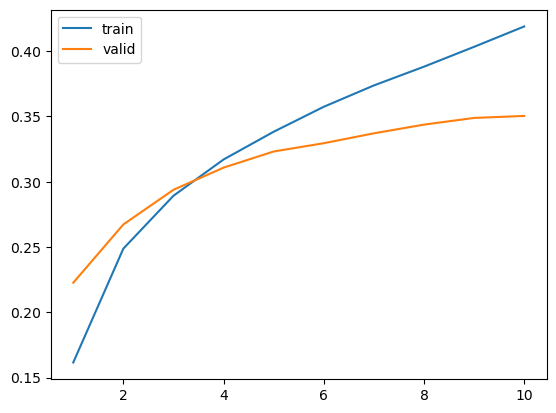

In [70]:
epoch_count = range(1, len(history1['accuracy']) + 1)
sns.lineplot(x=epoch_count,  y=history1['accuracy'], label='train')
sns.lineplot(x=epoch_count,  y=history1['val_accuracy'], label='valid')
plt.show()

### 5 - Inferencia
Experimentar el funcionamiento de su modelo. Recuerde que debe realizar la inferencia de los modelos por separado de encoder y decoder.

In [71]:
# Armar los conversores de indice a palabra:
idx2word_input = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

In [72]:
model.eval()  # desactivar dropout durante inferencia

input_test = "My mother say hi."
print('Input:', input_test)
integer_seq_test = input_tokenizer.texts_to_sequences([input_test])[0]
print("Representacion en vector de tokens de ids", integer_seq_test)
encoder_sequence_test = pad_sequences([integer_seq_test], maxlen=max_input_len)
print("Padding del vector:", encoder_sequence_test)
encoder_sequence_test_tensor = torch.from_numpy(encoder_sequence_test.astype(np.int32))

with torch.no_grad():
    # Se obtiene la salida del encoder (el estado oculto para el decoder)
    prev_state = model.encoder(encoder_sequence_test_tensor.to(device))

    # Se inicializa la secuencia de entrada al decoder como "<sos>"
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    target_seq_tensor = torch.from_numpy(target_seq.astype(np.int32))

    # Se obtiene la primera palabra de la secuencia de salida del decoder
    output, prev_state = model.decoder(target_seq_tensor.to(device), prev_state)

top1 = output.argmax(1).view(-1, 1)
idx = int(top1.cpu())
print("Index/token de salida:", idx)

word = idx2word_target[idx]
print("Palabra de salida:", word)

Input: My mother say hi.
Representacion en vector de tokens de ids [17, 212, 131, 2653]
Padding del vector: [[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
    17  212  131 2653]]
Index/token de salida: 20
Palabra de salida: mi


In [73]:
def translate_sentence(input_seq, strategy='greedy', temperature=1.0, top_k=0):
    """
    strategy:    'greedy' | 'sampling'
    temperature: > 1.0 = más aleatorio, < 1.0 = más conservador (solo aplica a sampling)
    top_k:       si > 0, samplea solo entre los top-k tokens más probables
    """
    model.eval()
    if isinstance(input_seq, np.ndarray):
        input_seq = torch.from_numpy(input_seq.astype(np.int32))

    with torch.no_grad():
        prev_state = model.encoder(input_seq.to(device))

        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = word2idx_outputs['<sos>']
        target_seq_tensor = torch.from_numpy(target_seq.astype(np.int32))

        eos = word2idx_outputs['<eos>']
        output_sentence = []

        for _ in range(max_out_len):
            logits, new_prev_state = model.decoder(target_seq_tensor.to(device), prev_state)
            # logits: (1, V) — raw, sin softmax

            if strategy == 'greedy':
                next_idx = int(logits.argmax(1).item())
            else:  # sampling
                scaled = logits / temperature
                if top_k > 0:
                    vals, idxs = scaled.topk(top_k, dim=-1)
                    probs = torch.softmax(vals, dim=-1)
                    pick = torch.multinomial(probs, 1)
                    next_idx = int(idxs.gather(-1, pick).item())
                else:
                    probs = torch.softmax(scaled, dim=-1)
                    next_idx = int(torch.multinomial(probs, 1).item())

            if next_idx == eos:
                break
            if next_idx > 0:
                output_sentence.append(idx2word_target[next_idx])

            prev_state = new_prev_state
            target_seq_tensor = torch.tensor([[next_idx]], dtype=torch.int32)

    return ' '.join(output_sentence)

In [74]:
input_test = "My mother say hi."
print('Input:', input_test)
integer_seq_test = input_tokenizer.texts_to_sequences([input_test])[0]
print("Representacion en vector de tokens de ids", integer_seq_test)
encoder_sequence_test = pad_sequences([integer_seq_test], maxlen=max_input_len)
print("Padding del vector:", encoder_sequence_test)
encoder_sequence_test_tensor = torch.from_numpy(encoder_sequence_test.astype(np.int32))

translation = translate_sentence(encoder_sequence_test)
print('Response:', translation)

Input: My mother say hi.
Representacion en vector de tokens de ids [17, 212, 131, 2653]
Padding del vector: [[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
    17  212  131 2653]]
Response: mi padre me ha ido


In [75]:
for _ in range(5):
    i = np.random.choice(len(input_sentences))
    input_seq = encoder_input_sequences[i:i+1]
    encoder_sequence_test_tensor = torch.from_numpy(input_seq.astype(np.int32))
    translation = translate_sentence(encoder_sequence_test_tensor)
    print('-')
    print('Input:', input_sentences[i])
    print('Response:', translation)

-
Input: Your work has greatly improved.
Response: no te preocupes lo que está pasando
-
Input: Tom is naked.
Response: tom está
-
Input: I can't hear you.
Response: no puedo ayudar
-
Input: I've got nothing to say to him.
Response: no tengo nada que hacer para ayudar
-
Input: She seemed to be suffering a heart attack.
Response: ella le contó a un poco de su hijo


#### Comparación de estrategias de generación
Para las mismas oraciones de entrada, comparamos **greedy** (argmax) vs **sampling** con distintas temperaturas. Sampling produce traducciones más variadas — a veces mejores, a veces peores.

In [76]:
np.random.seed(7)
indices = [np.random.choice(len(input_sentences)) for _ in range(5)]

for i in indices:
    input_seq = encoder_input_sequences[i:i+1]
    print('Input:    ', input_sentences[i])
    print('  greedy:    ', translate_sentence(input_seq, strategy='greedy'))
    print('  T=0.7:     ', translate_sentence(input_seq, strategy='sampling', temperature=0.7))
    print('  T=1.0:     ', translate_sentence(input_seq, strategy='sampling', temperature=1.0))
    print('  T=1.0 k=10:', translate_sentence(input_seq, strategy='sampling', temperature=1.0, top_k=10))
    print('-' * 60)

Input:     I have a new red car.
  greedy:     tengo una gran suma de
  T=0.7:      tengo un poco de un vecino
  T=1.0:      tengo sol monedas de un huevo
  T=1.0 k=10: no tengo un montón de
------------------------------------------------------------
Input:     Nobody believed you.
  greedy:     nadie está tu nombre
  T=0.7:      nadie ha comido eso
  T=1.0:      nadie está listo
  T=1.0 k=10: no lo estás ocultando
------------------------------------------------------------
Input:     They were caught red-handed.
  greedy:     tom estaba muy ocupado para él
  T=0.7:      tom estaba en su computador
  T=1.0:      tom fue al monedero
  T=1.0 k=10: tom estaba cubierto de ropa
------------------------------------------------------------
Input:     I didn't want to give Tom any money.
  greedy:     no quiero que tom no le agrada mary
  T=0.7:      no quiero conocer a tom ahora mismo
  T=1.0:      no quiero saber por qué le robé esto
  T=1.0 k=10: quiero saber dónde me hagan eso
----------

### 6 - Conclusiones

#### Tabla de seguimiento entre versiones

Resumen compacto de las iteraciones principales que llevaron a la configuración final, para ver el progreso de un vistazo.

| Iteración | Configuración | Train acc | Valid acc | Métrica |
|---|---|---|---|---|
| Sweep 128 | 6 000 seqs, 16/18, sin reg | ~0.870 | ~0.858 | inflada (cuenta padding) |
| Sweep 256 | 6 000 seqs, 16/18, sin reg | ~0.885 | ~0.860 | inflada (cuenta padding) |
| Sweep 512 | 6 000 seqs, 16/18, sin reg | ~0.915 | ~0.853 | inflada (cuenta padding) |
| Sin regularización | 25 000 seqs, 32/36, dropout 0 | 0.535 | 0.336 | enmascarada (sin padding) |
| Final | 25 000 seqs, 32/36, dropout 0.3 + AdamW + grad clip | 0.425 | 0.353 | enmascarada (sin padding) |

Las filas del sweep usan la métrica original sin máscara, por eso los números altos. A partir de "Sin regularización" se enmascara el padding y los valores reflejan acierto real sobre tokens no-pad. La fila "Final" tiene `train_acc` más bajo que "Sin regularización" pero mejor `valid_acc` y gap mucho más chico (0.07 vs 0.20), efecto esperado de la regularización.

---

Sweep de neuronas en la LSTM (con MAX_NUM_SENTENCES = 6 000, secuencias 16/18):
- 128 neuronas: train ~0.870 / valid ~0.858
- 256 neuronas: train ~0.885 / valid ~0.860
- 512 neuronas: train ~0.915 / valid ~0.853 (overfitting)
Se eligió 256 como mejor compromiso.

Configuración final (25 000 sentencias, secuencias 32/36, dropout 0.3, AdamW + weight decay, gradient clipping, FastText EN frozen + Word2Vec ES entrenable, 10 epochs): train acc ~0.42 / valid acc ~0.35, gap ~0.07.

La métrica `sequence_acc` de la versión original llegaba a ~0.85 porque contaba los tokens `<pad>` como aciertos. Con la máscara que los ignora baja a ~0.35, que refleja la calidad real a nivel de token no-pad.

Configuraciones del notebook original que impedían el aprendizaje:
- Doble softmax (decoder + CrossEntropyLoss) que aplastaba los gradientes y hacía colapsar el modelo a un único token. Fix: el decoder devuelve logits crudos.
- lr = 0.1 en Adam, demasiado agresivo. Bajado a 1e-3.
- Off-by-one en nb_words que causaba IndexError al crecer el vocabulario. Se sumó + 1.
- translate_sentence ignoraba su argumento y leía una variable global, traduciendo siempre la misma oración.

Efecto de la regularización (dropout 0.3 + AdamW con weight decay):

| | Sin regularización | Con regularización |
|---|---|---|
| Train acc | 0.535 | 0.425 |
| Valid acc | 0.336 | 0.353 |
| Gap | 0.20 | 0.07 |

Targets como índices int64 en lugar de one-hot float: ~5700× menos RAM. Sin ese cambio el kernel crasheaba al pasar de 6 000 a 25 000 sentencias.

Vectorización del decoder durante teacher forcing (toda la secuencia en una sola llamada al LSTM en vez de loop por timestep): ~10 a 20× más rápido por epoch.

Estrategias de generación: greedy es determinista; sampling con temperatura agrega variedad pero a T=1.0 sin top_k aparecen más errores. top_k=10 con T=1.0 da el mejor balance.

Inicialización del decoder con Word2Vec entrenado sobre el corpus: mejora marginal vs. inicialización aleatoria. Con 25k sentencias Word2Vec aprende vectores débiles, y el embedding entrenable se ajusta bien desde cero en pocas epochs. Para ver diferencia haría falta FastText español pre-entrenado en un corpus grande.

Las traducciones son gramaticalmente correctas en español pero el contenido no suele corresponderse con la entrada. Es lo esperable de un seq2seq sin atención: todo el input se comprime en un único vector de 256 dimensiones. El próximo paso lógico (no implementado) sería agregar atención.

#### Análisis cualitativo de las traducciones generadas:

El modelo captura de forma confiable los elementos estructurales más simples: pronombres y verbos de las primeras posiciones ("I have" / "tengo", "You are" / "eres/estás", "Nobody" / "nadie"). También suele preservar la polaridad (negación): "I didn\'t want" / "no quiero".

A partir del verbo, la generación se desacopla del input. Las palabras de contenido, "red", "early", "money", "red-handed", se pierden por completo. El decoder, sin atención, ya no tiene acceso útil al input y termina completando con n-gramas frecuentes del corpus de entrenamiento.

Hay un sesgo evidente del dataset: "tom" aparece en casi todas las traducciones de la oración "They were caught red-handed", aunque la entrada no lo menciona. El nombre está sobre-representado en las oraciones de Tatoeba y el modelo lo elige cuando no tiene un sujeto claro.

Los idiomas como "red-handed" fallan completamente, el modelo nunca vio esa expresión asociada a una traducción correcta y la trata como dos palabras independientes.

Greedy y sampling con T=0.7 comparten la palabra inicial casi siempre (tengo, nadie, no quiero, eres). El modelo está seguro de los primeros 1 a 2 tokens y la incertidumbre crece rápido a partir del tercero, donde sampling diverge. T=1.0 sin top_k produce errores léxicos extraños ("sol monedas de un huevo"); top_k=10 reduce esa rareza pero a veces pierde el sujeto correcto.

La tensión verbal también se pierde: "I didn\'t want" (pasado) / "no quiero" (presente). El decoder no recibe señal de tiempo desde el encoder.

#### Trabajo futuro:
- Atención: elimina el cuello de botella del único vector encoder/decoder. Es el cambio de mayor impacto sobre la calidad de las traducciones.
- Encoder bidireccional (`nn.LSTM(..., bidirectional=True)`): cambio mínimo, suele dar +0.01 a 0.03 de valid acc.
- Beam search en inferencia (en vez de greedy/sampling): típicamente +1 a 3 BLEU.
- Tokenización subword (BPE / SentencePiece): elimina los `<unk>`, mejora el manejo de palabras raras.
- Más epochs: las curvas siguen subiendo en epoch 10, el modelo no llegó a converger.
- FastText español pre-entrenado en un corpus grande, en lugar de Word2Vec sobre 25k sentencias.
- BLEU como métrica adicional: la token accuracy enmascarada ya es honesta, pero BLEU es el estándar en traducción y permite comparar contra otros sistemas.